<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Liverpool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Liverpool

#Tendencia
##Medias Móviles

In [2]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01')

/tmp/ipykernel_6359/1046451472.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


###Media Móvil Simple

In [3]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

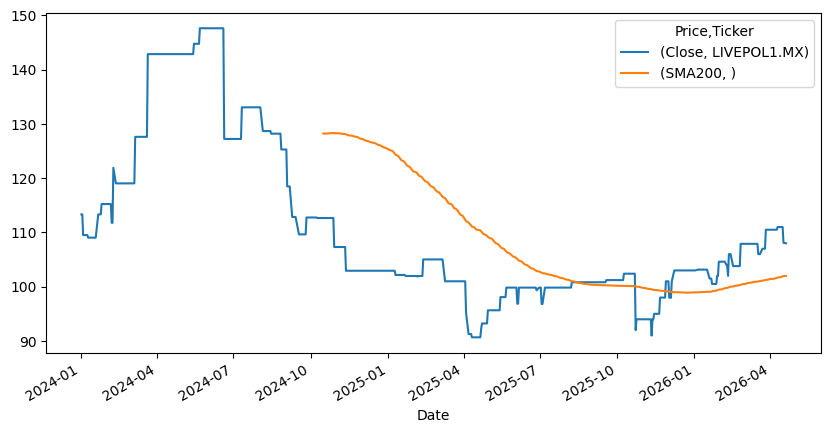

In [4]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [5]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [6]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

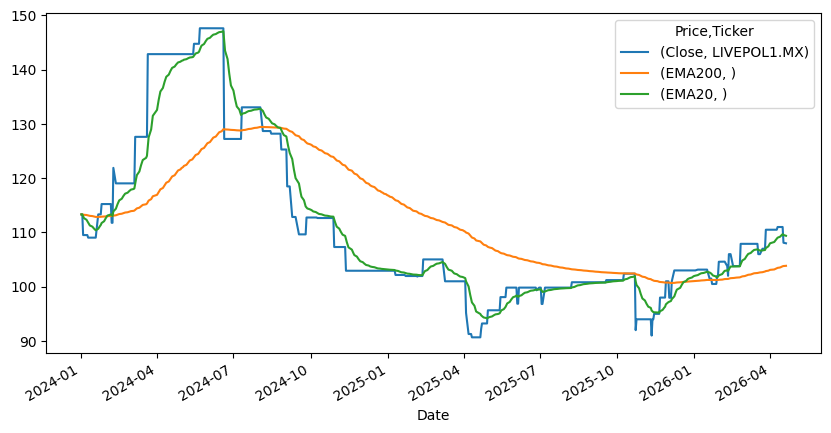

In [7]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

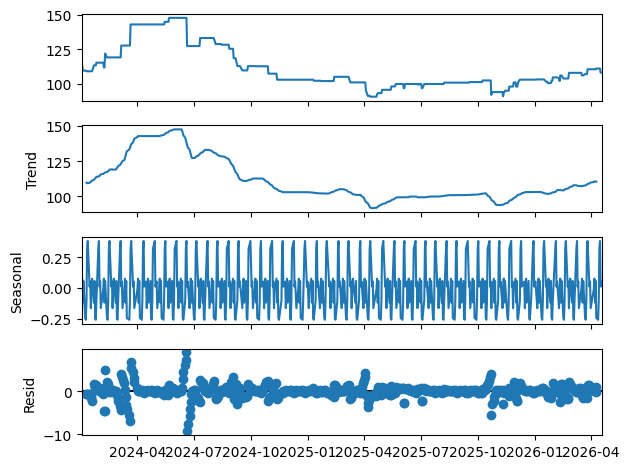

In [8]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()


###Modelo Multiplicativo

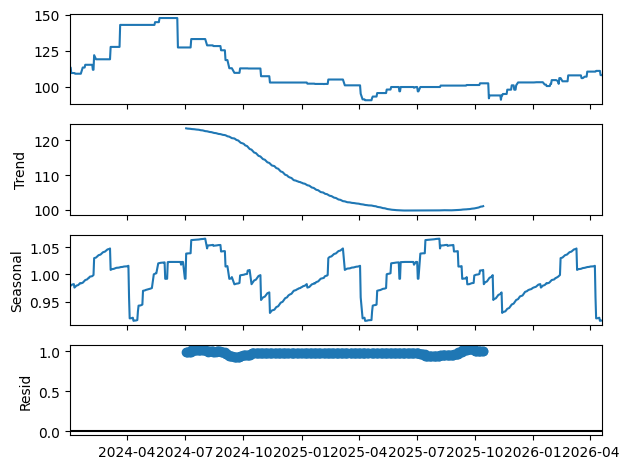

In [9]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()


##Serie Estacionaria


In [ ]:
#Obtener datos
precios = df['Close']

In [ ]:
# Transformación a retornos porcentuales (diferenciación)
# Los precios suelen ser no estacionarios, los retornos sí lo son.
retornos = precios.pct_change().dropna()

In [ ]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [ ]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.6515
Valor p: 0.9888
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9888176069723107)

In [ ]:
# Ejecutar prueba en Retornos (Transformados)
probar_estacionariedad(retornos, "Retornos Porcentuales")


--- Prueba ADF para: Retornos Porcentuales ---
Estadístico de Dickey-Fuller: -26.4905
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

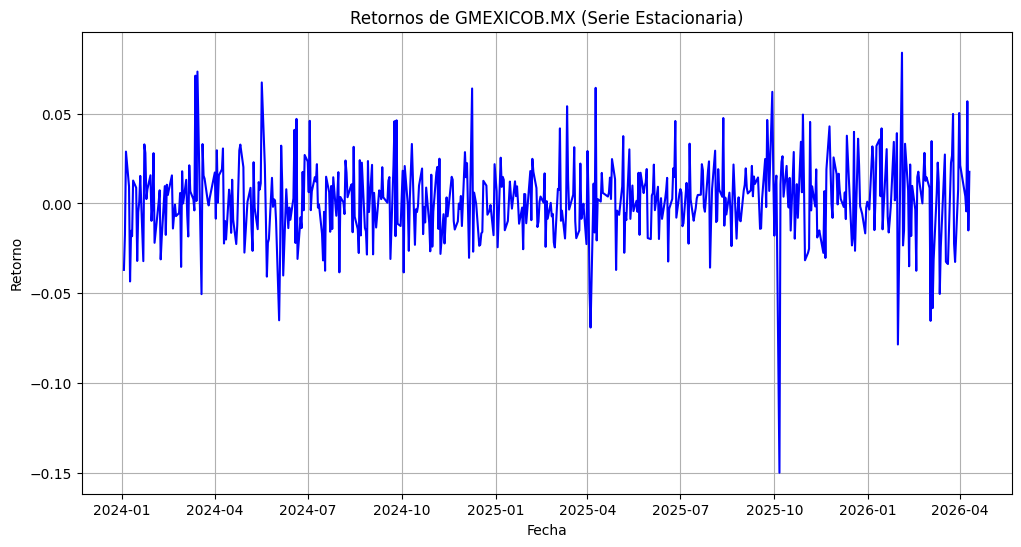

In [ ]:
# Visualización
plt.figure(figsize=(12, 6))
plt.plot(retornos, label=f'Retornos de {'GMEXICOB.MX'}', color='blue')
plt.title(f'Retornos de {'GMEXICOB.MX'} (Serie Estacionaria)')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.grid(True)
plt.show()

##Diferenciando para hacer estacionaria la serie

Head of the differenced price series:
Ticker      GMEXICOB.MX
Date                   
2024-01-03    -3.156296
2024-01-04    -1.423088
2024-01-05     2.326180
2024-01-08     0.784515
2024-01-09    -3.639771


<Figure size 1000x500 with 0 Axes>

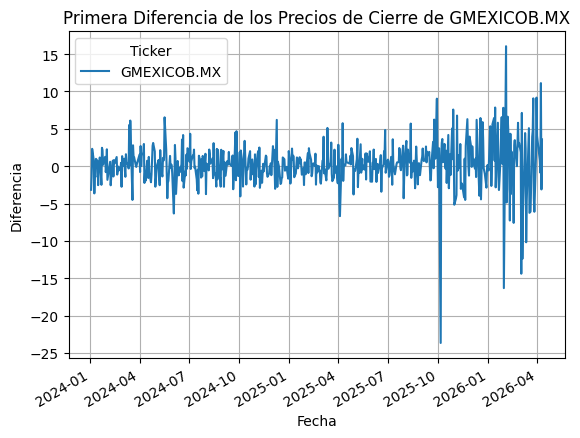

In [ ]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = df['Close'].diff().dropna()

# Mostrar los primeros elementos de la serie diferenciada
print("Head of the differenced price series:")
print(differenced_prices.head())

# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [ ]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -27.2212
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0